Normalized SSD - Nearest: 136.27, Bilinear: 115.09


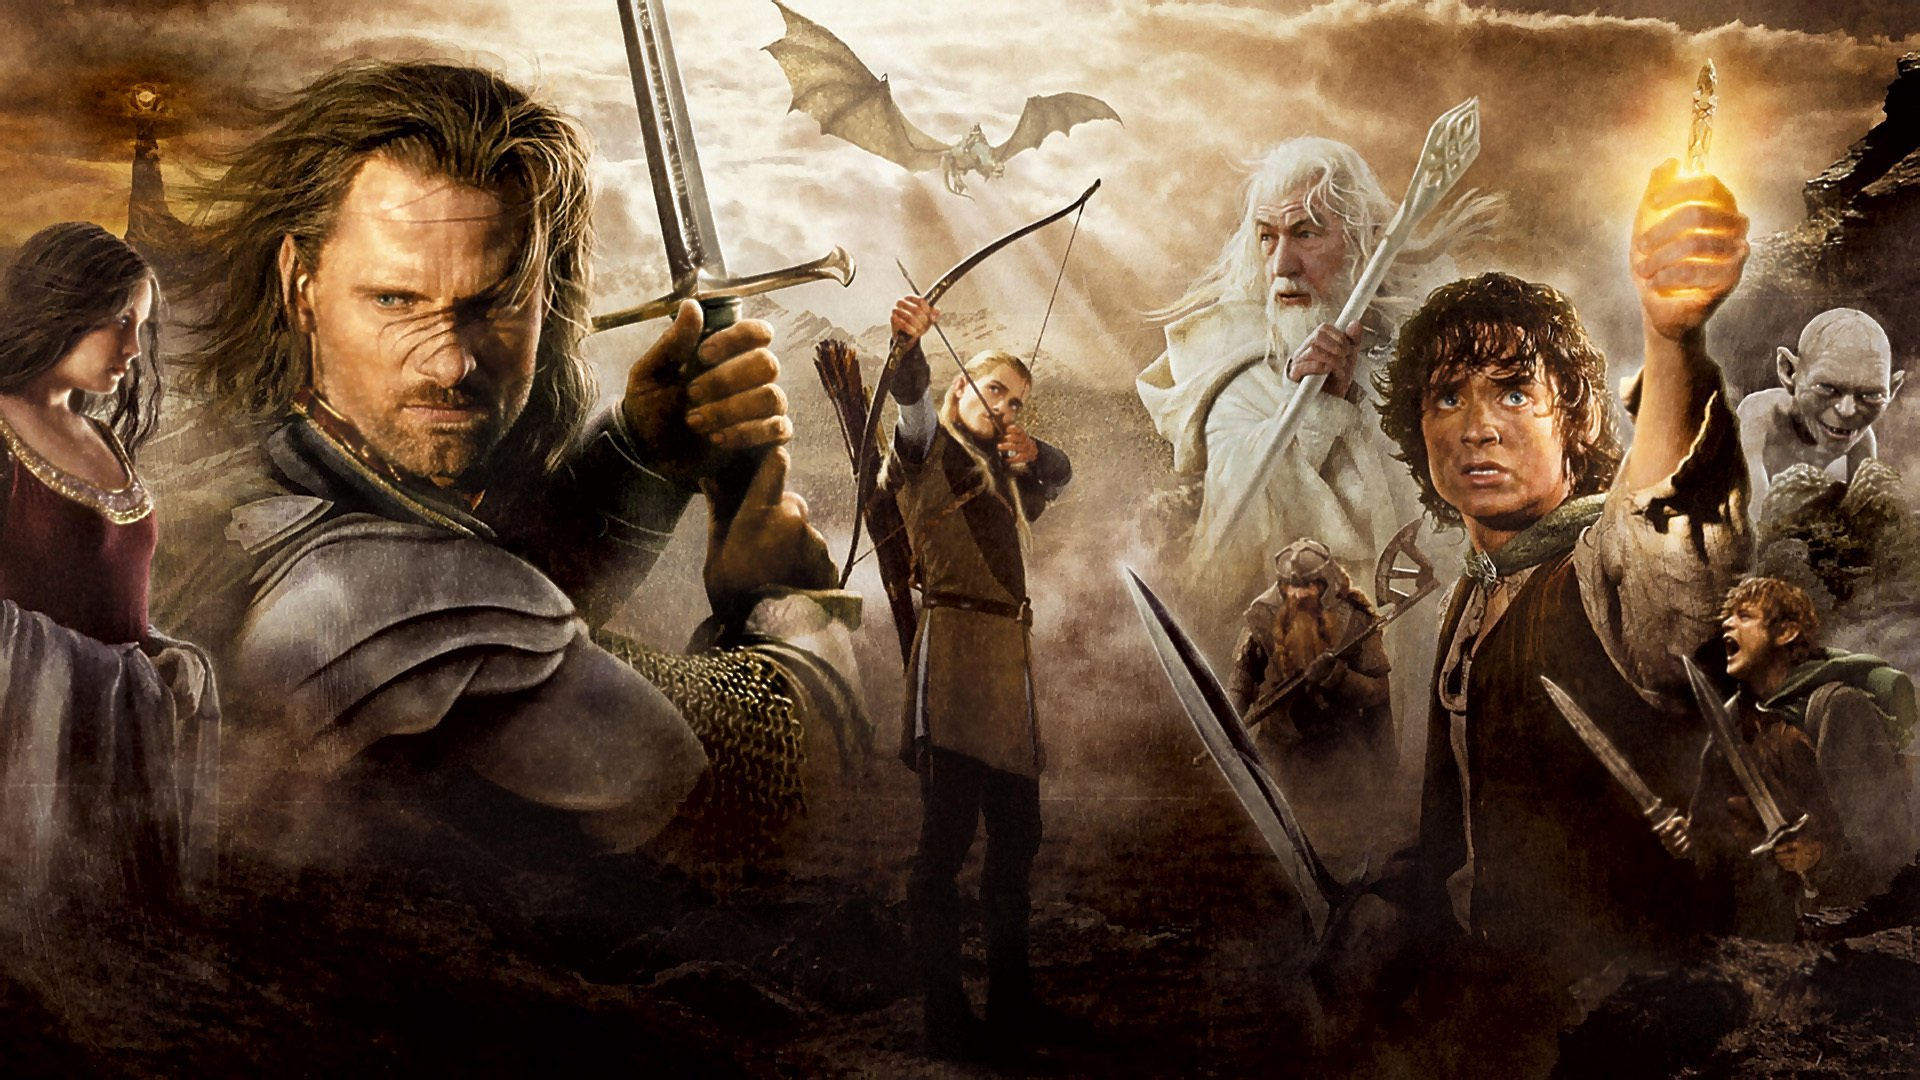

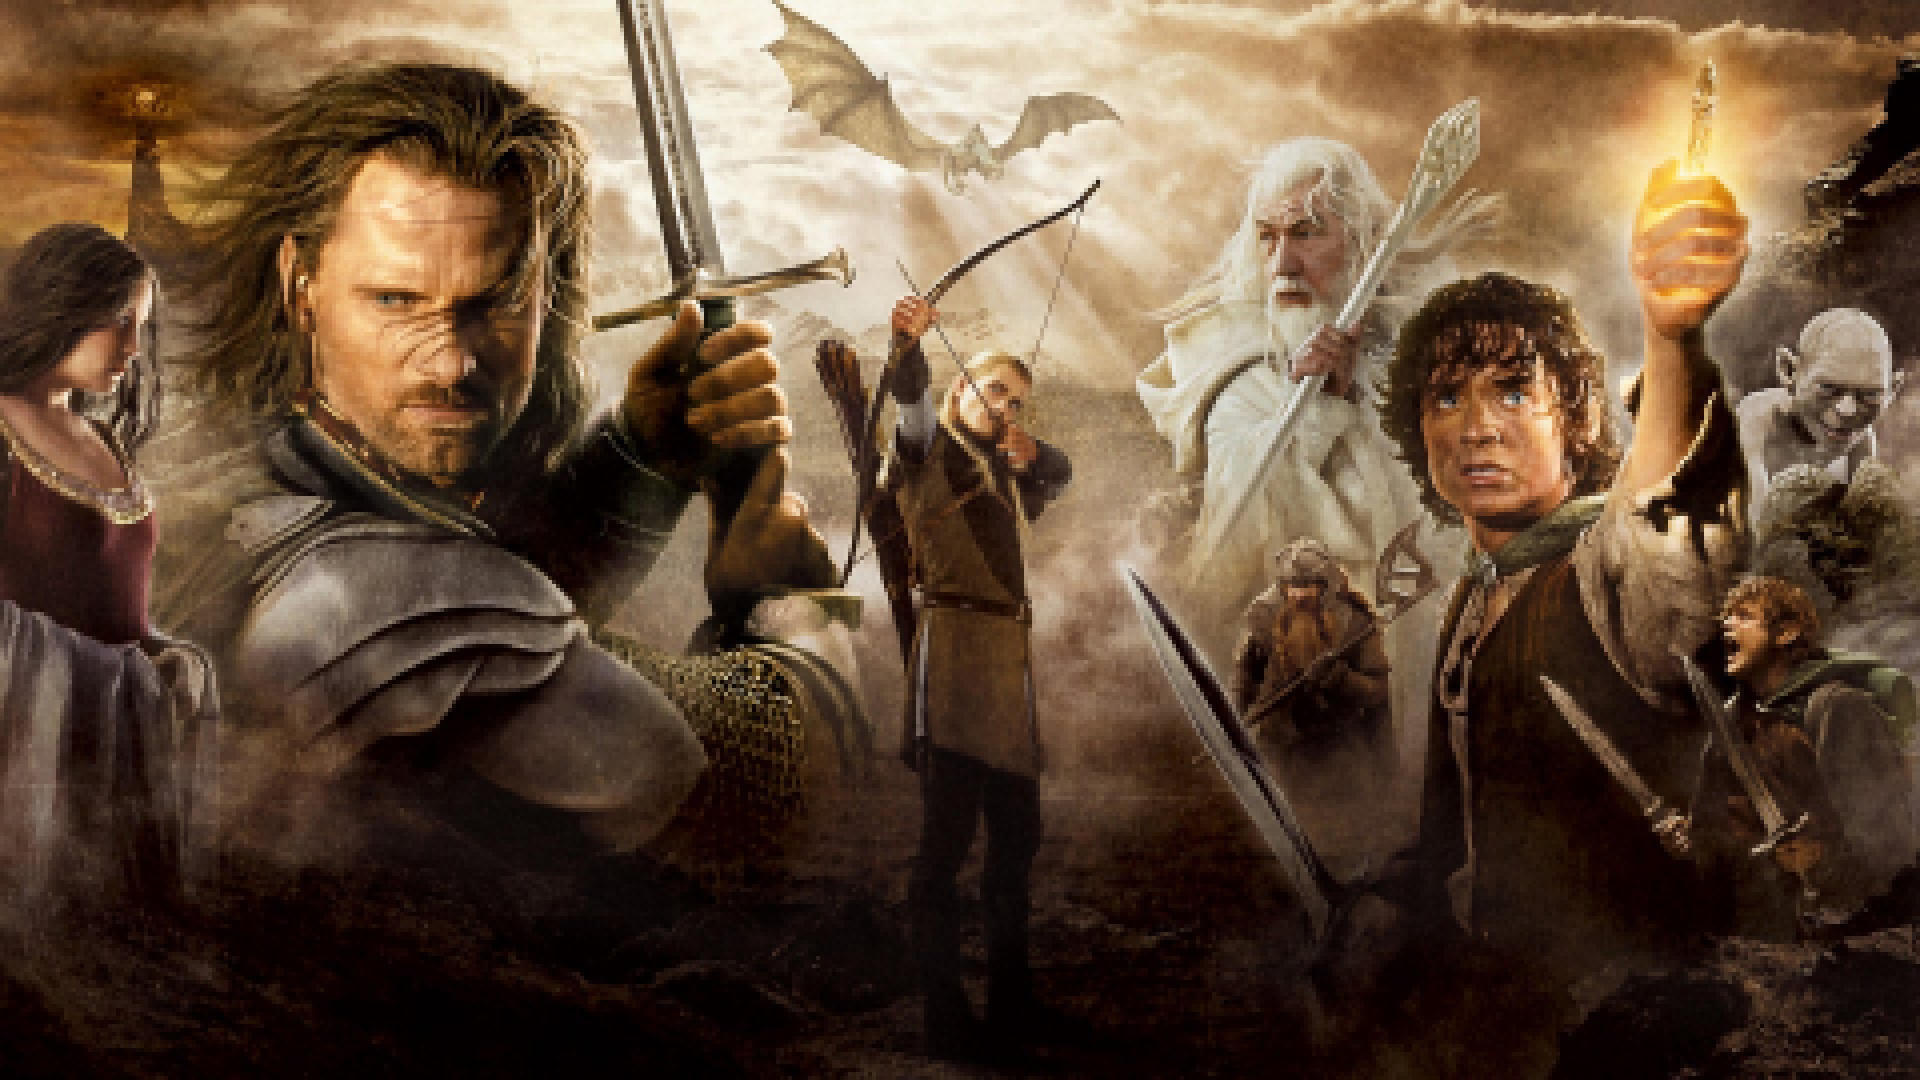

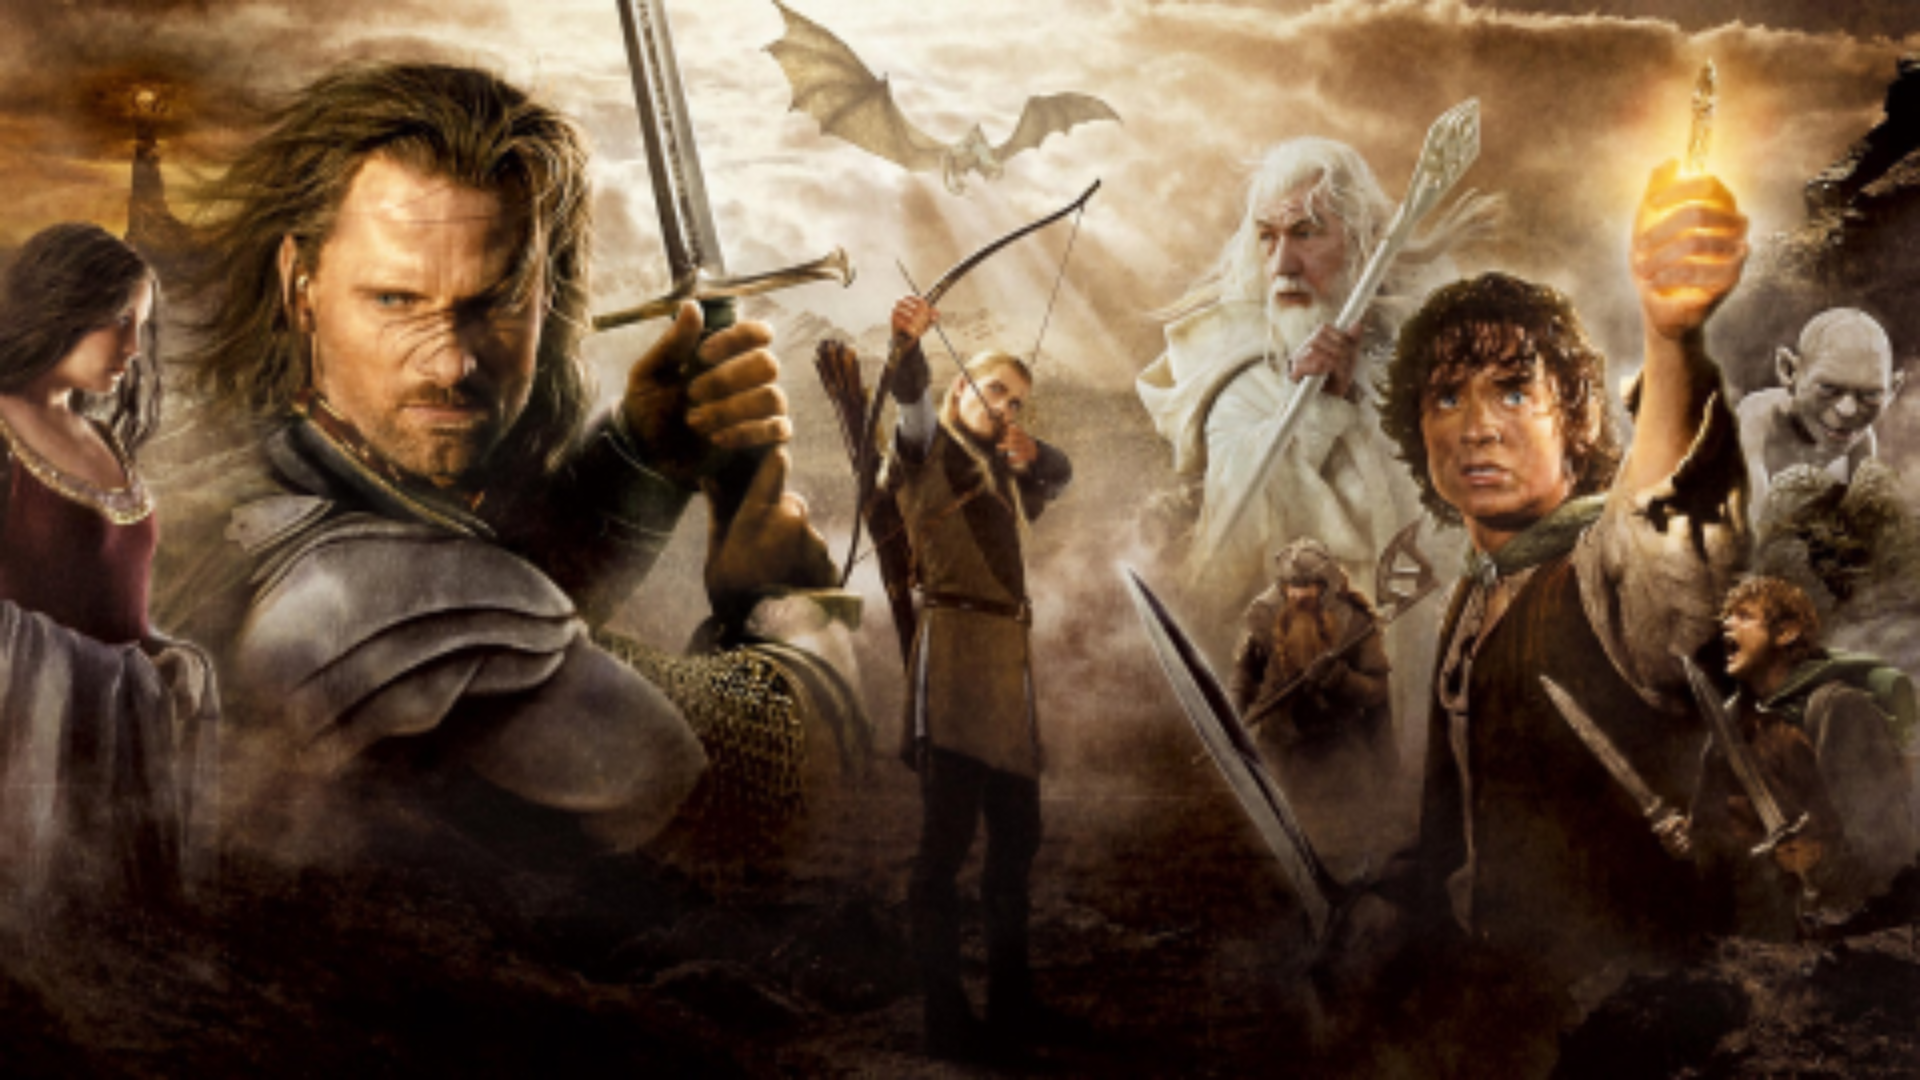

In [11]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

def zoom_image(img, scale, method='nearest', target_shape=None):
    interpolation = cv2.INTER_NEAREST if method=='nearest' else cv2.INTER_LINEAR
    h, w = img.shape[:2]
    new_size = (int(w*scale), int(h*scale))
    zoomed = cv2.resize(img, new_size, interpolation=interpolation)

    if target_shape is not None:
        zoomed = cv2.resize(zoomed, (target_shape[1], target_shape[0]), interpolation=interpolation)
    return zoomed

def normalized_ssd(img1, img2):
    diff = img1.astype(np.float32) - img2.astype(np.float32)
    return np.sum(diff**2) / np.prod(img1.shape)

small_img1 = cv2.imread('/content/sample_data/im01small.png')
large_img1 = cv2.imread('/content/sample_data/im01.png')

scale_factor = 4

zoomed_nn = zoom_image(small_img1, scale_factor, method='nearest', target_shape=large_img1.shape)
zoomed_bl = zoom_image(small_img1, scale_factor, method='bilinear', target_shape=large_img1.shape)

ssd_nn = normalized_ssd(zoomed_nn, large_img1)
ssd_bl = normalized_ssd(zoomed_bl, large_img1)

print(f"Normalized SSD - Nearest: {ssd_nn:.2f}, Bilinear: {ssd_bl:.2f}")


cv2_imshow(large_img1)
cv2_imshow(zoomed_nn)
cv2_imshow(zoomed_bl)